# Experiment 7.3.1 — Frozen-L2 Linear Optimization and Same-W LIF Substitution

Analysis-only notebook. It reads finalized Exp7.3.1 artifacts; no training or job submission is performed here.


In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start=Path.cwd()):
    cur = start.resolve()
    for candidate in (cur, *cur.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "scripts").exists():
            return candidate
    raise FileNotFoundError("Could not find repository root")

REPO_ROOT = find_repo_root()
ROOT = REPO_ROOT / "notebooks" / "artifacts" / "experiment_7_3_1_frozen_l2_linear_optimization" / "frozen_l2_linear_optimization_v1"
manifest = json.loads((ROOT / "manifest.json").read_text())
runs = pd.read_csv(ROOT / "method_runs.csv")
summary = pd.read_csv(ROOT / "method_summary.csv")
contrasts = pd.read_csv(ROOT / "contrast_summary.csv")
selected_reg = pd.read_csv(ROOT / "selected_regularization.csv")
manifest


{'adam_c0_epoch_limit': 100,
 'adam_epochs': 500,
 'architecture': '234x234',
 'backbone_objectives': ['tsce', 'wcce'],
 'cases': ['C0_adam100',
  'C1_adam500',
  'C2_lbfgs_noreg',
  'C3_lbfgs_reg',
  'C4_scale_lbfgs_reg',
  'Ref_scale_lbfgs_converged'],
 'deployment_contract': 'Every selected Linear W is evaluated unchanged through the same beta=0.5, threshold=0.5, cap=1 output LIF spike-count simulator; no LIF retraining or gain/threshold/beta sweep.',
 'experiment_id': 'experiment_7_3_1_frozen_l2_linear_optimization',
 'head_objectives': ['tsce', 'wcce'],
 'lbfgs_max_eval': 100,
 'legacy_probe_note': 'Exp7.3 StandardScaler+intercept probes are reported only as auxiliary accessibility references, not as exact same-W LIF-deployable heads.',
 'logical_rows': 72,
 'physical_tasks': {'C2_lbfgs_noreg': 12,
  'C3_candidates': 60,
  'C4_candidates': 60,
  'Ref_candidates': 60,
  'adam_shared_C0_C1': 12},
 'protocol_version': 'frozen_l2_linear_optimization_v1',
 'ref_max_eval': 5000,
 'reg_l

## Selected method table

Each row below is a finalized case averaged over seeds. `analog_test_ba` uses the trained Linear W; `lif_test_ba` uses the exact same W through the fixed output LIF.


In [2]:
cols = [
    "backbone_objective", "head_objective", "case",
    "analog_test_ba_mean", "analog_test_ba_std",
    "lif_test_ba_mean", "lif_test_ba_std",
    "analog_to_lif_gap_pp_mean", "reg_lambda_mean",
]
display(summary[cols].sort_values(["backbone_objective", "head_objective", "case"]))


,backbone_objective,head_objective,case,analog_test_ba_mean,analog_test_ba_std,lif_test_ba_mean,lif_test_ba_std,analog_to_lif_gap_pp_mean,reg_lambda_mean
0,tsce,tsce,C0_adam100,0.466340,0.034225,0.436928,0.034130,2.941156,0.0000
1,tsce,tsce,C1_adam500,0.478868,0.048569,0.454314,0.038198,2.455415,0.0000
2,tsce,tsce,C2_lbfgs_noreg,0.473825,0.035796,0.367112,0.047160,10.671319,0.0000
3,tsce,tsce,C3_lbfgs_reg,0.476916,0.054888,0.360200,0.016085,11.671592,0.0037
4,tsce,tsce,C4_scale_lbfgs_reg,0.482034,0.041875,0.380309,0.038691,10.172513,0.0070
5,tsce,tsce,Ref_scale_lbfgs_converged,0.484560,0.041532,0.380309,0.038691,10.425038,0.0070
6,tsce,wcce,C0_adam100,0.511073,0.043053,0.497301,0.050861,1.377234,0.0000
7,tsce,wcce,C1_adam500,0.509815,0.032781,0.484281,0.019543,2.553442,0.0000
8,tsce,wcce,C2_lbfgs_noreg,0.457515,0.050383,0.321859,0.023425,13.565601,0.0000
9,tsce,wcce,C3_lbfgs_reg,0.505686,0.003135,0.393365,0.012005,11.232124,0.0037


## Analog test BA across optimization cases


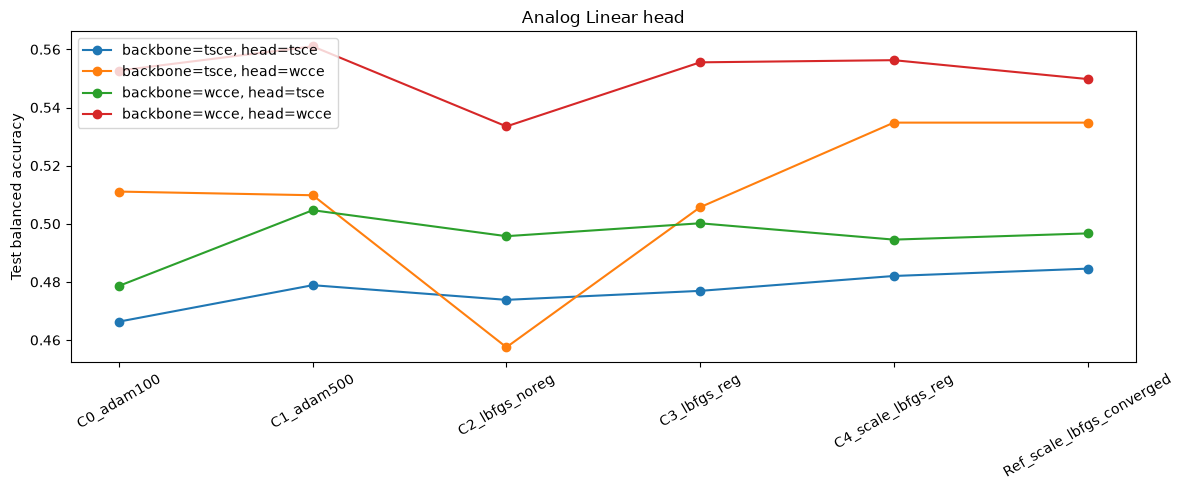

In [3]:
case_order = manifest["cases"]
fig, ax = plt.subplots(figsize=(12, 5))
labels = []
series = []
for backbone in manifest["backbone_objectives"]:
    for objective in manifest["head_objectives"]:
        sub = summary[(summary.backbone_objective == backbone) & (summary.head_objective == objective)].set_index("case")
        vals = [sub.loc[case, "analog_test_ba_mean"] for case in case_order]
        labels.append(f"backbone={backbone}, head={objective}")
        series.append(vals)
for label, vals in zip(labels, series):
    ax.plot(case_order, vals, marker="o", label=label)
ax.set_ylabel("Test balanced accuracy")
ax.set_title("Analog Linear head")
ax.tick_params(axis="x", rotation=30)
ax.legend()
plt.tight_layout()
plt.show()


## Same-W LIF test BA


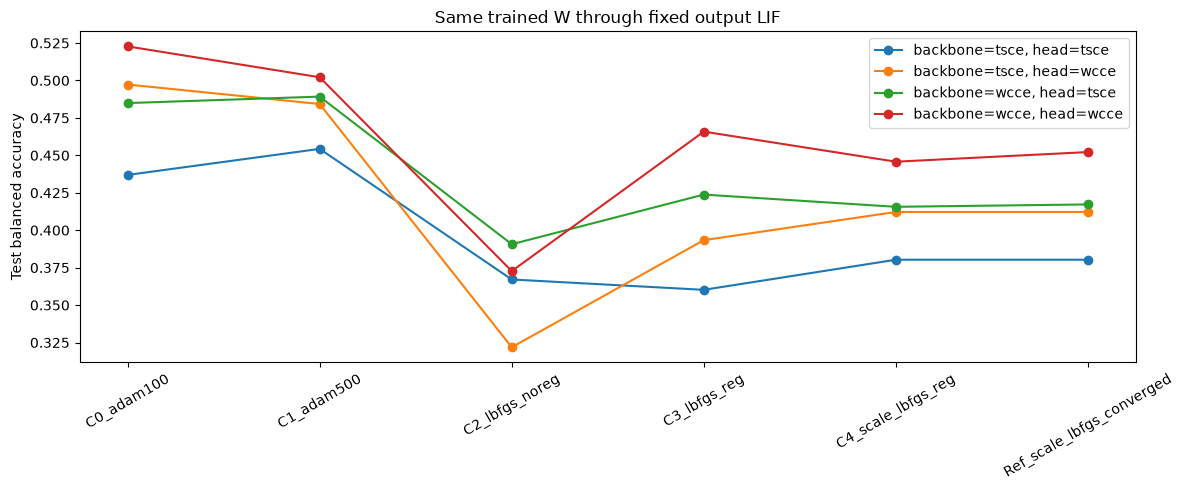

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
for label, vals in zip(labels, [
    [summary[(summary.backbone_objective == backbone) & (summary.head_objective == objective)].set_index("case").loc[case, "lif_test_ba_mean"] for case in case_order]
    for backbone in manifest["backbone_objectives"]
    for objective in manifest["head_objectives"]
]):
    ax.plot(case_order, vals, marker="o", label=label)
ax.set_ylabel("Test balanced accuracy")
ax.set_title("Same trained W through fixed output LIF")
ax.tick_params(axis="x", rotation=30)
ax.legend()
plt.tight_layout()
plt.show()


## Analog → LIF interface gap


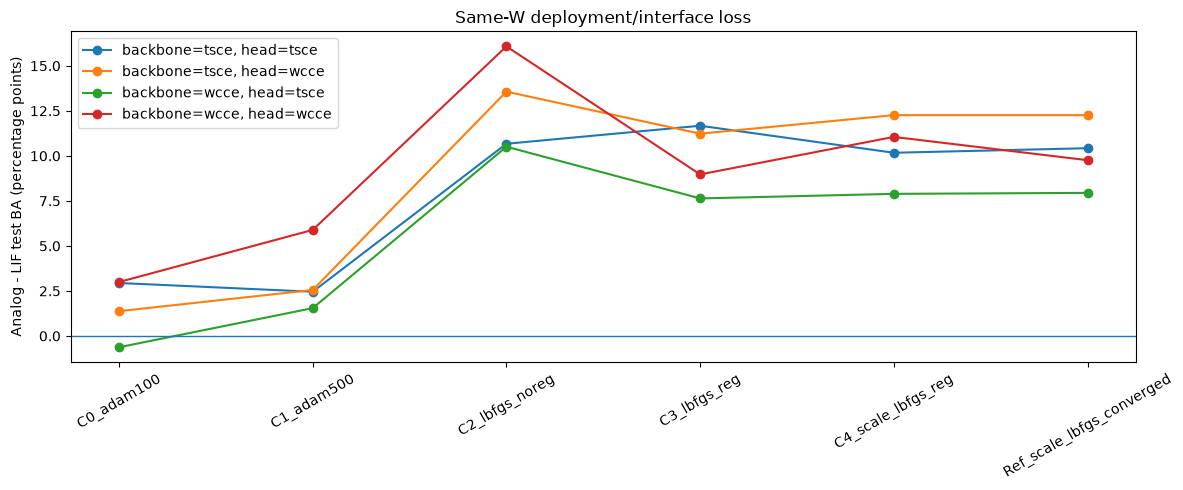

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
for backbone in manifest["backbone_objectives"]:
    for objective in manifest["head_objectives"]:
        sub = summary[(summary.backbone_objective == backbone) & (summary.head_objective == objective)].set_index("case")
        vals = [sub.loc[case, "analog_to_lif_gap_pp_mean"] for case in case_order]
        ax.plot(case_order, vals, marker="o", label=f"backbone={backbone}, head={objective}")
ax.axhline(0, linewidth=1)
ax.set_ylabel("Analog - LIF test BA (percentage points)")
ax.set_title("Same-W deployment/interface loss")
ax.tick_params(axis="x", rotation=30)
ax.legend()
plt.tight_layout()
plt.show()


## Optimization loss and selected regularization


In [6]:
display(
    summary[[
        "backbone_objective", "head_objective", "case",
        "train_task_ce_mean", "val_task_ce_mean",
        "reg_lambda_mean", "weight_norm_raw_mean",
    ]].sort_values(["backbone_objective", "head_objective", "case"])
)
display(selected_reg.sort_values(["backbone_objective", "head_objective", "case", "seed"]))


,backbone_objective,head_objective,case,train_task_ce_mean,val_task_ce_mean,reg_lambda_mean,weight_norm_raw_mean
0,tsce,tsce,C0_adam100,1.658719,2.034462,0.0000,5.324762
1,tsce,tsce,C1_adam500,1.571130,2.089203,0.0000,8.493042
2,tsce,tsce,C2_lbfgs_noreg,1.478058,2.208592,0.0000,13.404624
3,tsce,tsce,C3_lbfgs_reg,1.521325,2.138153,0.0037,9.066444
4,tsce,tsce,C4_scale_lbfgs_reg,1.493711,2.135179,0.0070,10.301630
5,tsce,tsce,Ref_scale_lbfgs_converged,1.493708,2.135212,0.0070,10.302858
6,tsce,wcce,C0_adam100,1.070267,1.576771,0.0000,7.569322
7,tsce,wcce,C1_adam500,0.567798,1.368850,0.0000,18.234040
8,tsce,wcce,C2_lbfgs_noreg,0.018746,682.773783,0.0000,21446.844413
9,tsce,wcce,C3_lbfgs_reg,0.548953,1.536215,0.0037,23.244246


,seed,backbone_objective,head_objective,case,reg_lambda
0,11,tsce,tsce,C3_lbfgs_reg,0.0010
12,23,tsce,tsce,C3_lbfgs_reg,0.0100
24,37,tsce,tsce,C3_lbfgs_reg,0.0001
1,11,tsce,tsce,C4_scale_lbfgs_reg,0.0100
13,23,tsce,tsce,C4_scale_lbfgs_reg,0.0100
25,37,tsce,tsce,C4_scale_lbfgs_reg,0.0010
2,11,tsce,tsce,Ref_scale_lbfgs_converged,0.0100
14,23,tsce,tsce,Ref_scale_lbfgs_converged,0.0100
26,37,tsce,tsce,Ref_scale_lbfgs_converged,0.0010
3,11,tsce,wcce,C3_lbfgs_reg,0.0001


## Pre-registered contrasts


In [7]:
display(contrasts.sort_values(["contrast", "backbone_objective", "head_objective"]))


,contrast,backbone_objective,head_objective,left_case,right_case,analog_delta_pp_count,analog_delta_pp_mean,analog_delta_pp_std,lif_delta_pp_count,lif_delta_pp_mean,lif_delta_pp_std
0,C1_minus_C0_extra_adam_budget,tsce,tsce,C1_adam500,C0_adam100,3,1.252844,1.598131,3,1.738585,2.724432
5,C1_minus_C0_extra_adam_budget,tsce,wcce,C1_adam500,C0_adam100,3,-0.125800,1.029656,3,-1.302008,3.170213
10,C1_minus_C0_extra_adam_budget,wcce,tsce,C1_adam500,C0_adam100,3,2.603114,2.206365,3,0.431097,0.805255
15,C1_minus_C0_extra_adam_budget,wcce,wcce,C1_adam500,C0_adam100,3,0.832293,0.404667,3,-2.061711,3.368251
1,C2_minus_C0_lbfgs_vs_adam100,tsce,tsce,C2_lbfgs_noreg,C0_adam100,3,0.748534,1.491936,3,-6.981629,6.462498
6,C2_minus_C0_lbfgs_vs_adam100,tsce,wcce,C2_lbfgs_noreg,C0_adam100,3,-5.355871,5.950008,3,-17.544238,7.329675
11,C2_minus_C0_lbfgs_vs_adam100,wcce,tsce,C2_lbfgs_noreg,C0_adam100,3,1.709494,1.370538,3,-9.425135,0.460496
16,C2_minus_C0_lbfgs_vs_adam100,wcce,wcce,C2_lbfgs_noreg,C0_adam100,3,-1.921366,3.395109,3,-15.005828,3.372272
2,C3_minus_C2_regularization,tsce,tsce,C3_lbfgs_reg,C2_lbfgs_noreg,3,0.309066,1.994709,3,-0.691207,3.973191
7,C3_minus_C2_regularization,tsce,wcce,C3_lbfgs_reg,C2_lbfgs_noreg,3,4.817150,5.108810,3,7.150627,2.065924
